In [23]:
# 02 - Model Development

import pickle

import numpy as np
import pandas as pd

from pathlib import Path

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

import xgboost as xgb

from src.preprocessing import load_raw_data, preprocess_and_split
from src.feature_engineering import apply_all_feature_engineering

DATA_PATH = Path("..") / "data" / "raw" / "german_credit_data.csv"

print(f"Loading data from: {DATA_PATH.resolve()}")

df = load_raw_data(str(DATA_PATH))
df = apply_all_feature_engineering(df)

preprocessed = preprocess_and_split(df)

X_train, X_test = preprocessed.X_train, preprocessed.X_test
y_train, y_test = preprocessed.y_train, preprocessed.y_test

print(X_train.shape, X_test.shape)


Loading data from: D:\projects\credit-risk-ml-pipeline\data\raw\german_credit_data.csv
(8000, 32) (2000, 32)


In [24]:
import pandas as pd

X_train = pd.read_csv("../data/processed/X_train.csv")
X_test = pd.read_csv("../data/processed/X_test.csv")
y_train = pd.read_csv("../data/processed/y_train.csv").values.ravel()
y_test = pd.read_csv("../data/processed/y_test.csv").values.ravel()

print(X_train.shape, X_test.shape)


(8000, 26) (2000, 26)


MODEL 1 — Logistic Regression (Baseline)

In [25]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(random_state=42, max_iter=1000))
])

lr_pipeline.fit(X_train, y_train)


Pipeline(steps=[('scaler', StandardScaler()),
                ('classifier',
                 LogisticRegression(max_iter=1000, random_state=42))])

In [26]:
y_pred_lr = lr_pipeline.predict(X_test)

print("Logistic Regression Metrics:")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall:", recall_score(y_test, y_pred_lr))
print("F1 Score:", f1_score(y_test, y_pred_lr))


Logistic Regression Metrics:
Accuracy: 0.8545
Precision: 0.7976190476190477
Recall: 0.7756874095513748
F1 Score: 0.7865003668378577


MODEL 2 — Decision Tree

In [27]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train, y_train)


DecisionTreeClassifier(random_state=42)

In [28]:
y_pred_dt = dt_model.predict(X_test)

print("Decision Tree Metrics:")
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt))
print("Recall:", recall_score(y_test, y_pred_dt))
print("F1 Score:", f1_score(y_test, y_pred_dt))


Decision Tree Metrics:
Accuracy: 0.864
Precision: 0.7980085348506402
Recall: 0.8118668596237337
F1 Score: 0.8048780487804879


MODEL 3 — Random Forest

In [10]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)


RandomForestClassifier(random_state=42)

In [11]:
y_pred_rf = rf_model.predict(X_test)

print("Random Forest Metrics:")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))


Random Forest Metrics:
Accuracy: 0.8915
Precision: 0.8516320474777448
Recall: 0.8306801736613604
F1 Score: 0.841025641025641


MODEL 4 — XGBoost

In [12]:
import xgboost as xgb

xgb_model = xgb.XGBClassifier(
    random_state=42,
    eval_metric='logloss'
)

xgb_model.fit(X_train, y_train)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, gpu_id=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, predictor=None, random_state=42, ...)

In [13]:
y_pred_xgb = xgb_model.predict(X_test)

print("XGBoost Metrics:")
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("Precision:", precision_score(y_test, y_pred_xgb))
print("Recall:", recall_score(y_test, y_pred_xgb))
print("F1 Score:", f1_score(y_test, y_pred_xgb))


XGBoost Metrics:
Accuracy: 0.894
Precision: 0.8406827880512091
Recall: 0.8552821997105644
F1 Score: 0.8479196556671449


In [15]:
recall_score(y_test, y_pred_lr)


0.7756874095513748

In [16]:
recall_score(y_test, y_pred_dt)


0.8118668596237337

In [17]:
recall_score(y_test, y_pred_rf)


0.8306801736613604

In [18]:
recall_score(y_test, y_pred_xgb)

0.8552821997105644

In [19]:
y_proba_lr = lr_pipeline.predict_proba(X_test)[:, 1]
y_proba_dt = dt_model.predict_proba(X_test)[:, 1]
y_proba_rf = rf_model.predict_proba(X_test)[:, 1]
y_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

In [32]:
import importlib
import src.feature_engineering as fe

importlib.reload(fe)

from src.feature_engineering import evaluate_model

In [33]:
from src.feature_engineering import evaluate_model


results = {
    "Logistic Regression": evaluate_model(y_test, y_pred_lr, y_proba_lr),
    "Decision Tree": evaluate_model(y_test, y_pred_dt, y_proba_dt),
    "Random Forest": evaluate_model(y_test, y_pred_rf, y_proba_rf),
    "XGBoost": evaluate_model(y_test, y_pred_xgb, y_proba_xgb)
}

In [34]:
comparison_df = pd.DataFrame(results).T
comparison_df


,Accuracy,Precision,Recall,F1-Score,AUC-ROC
Logistic Regression,0.8545,0.797619,0.775687,0.786500,0.924163
Decision Tree,0.8640,0.798009,0.811867,0.804878,0.851694
Random Forest,0.8915,0.851632,0.830680,0.841026,0.954785
XGBoost,0.8940,0.840683,0.855282,0.847920,0.968474


<Figure size 1000x600 with 0 Axes>

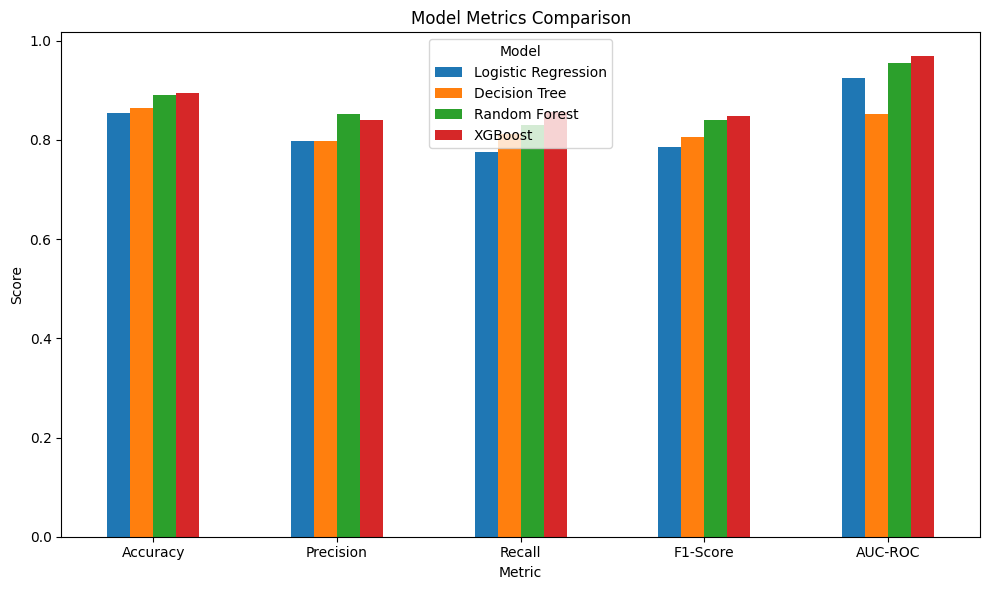

In [ ]:
import matplotlib.pyplot as plt
from pathlib import Path

# comparison_df: index = models, columns = ["Accuracy", "Precision", "Recall", "F1-Score", "AUC-ROC"]
metrics_order = ["Accuracy", "Precision", "Recall", "F1-Score", "AUC-ROC"]
plot_df = comparison_df[metrics_order].T   # rows = metrics, columns = models

plt.figure(figsize=(10, 6))
plot_df.plot(kind="bar", figsize=(10, 6))
plt.xlabel("Metric")
plt.ylabel("Score")
plt.title("Model Metrics Comparison")
plt.xticks(rotation=0)
plt.legend(title="Model")
plt.tight_layout()

# optional: save to reports/figures
figures_dir = Path("..") / "reports" / "figures"
figures_dir.mkdir(parents=True, exist_ok=True)
plt.savefig(figures_dir / "model_metric_comparison.png", dpi=300, bbox_inches="tight")

plt.show()

In [35]:
from pathlib import Path
import pickle

models_dir = Path("..") / "models"
models_dir.mkdir(parents=True, exist_ok=True)

with open(models_dir / "logistic_regression.pkl", "wb") as f:
    pickle.dump(lr_pipeline, f)

with open(models_dir / "decision_tree.pkl", "wb") as f:
    pickle.dump(dt_model, f)

with open(models_dir / "random_forest.pkl", "wb") as f:
    pickle.dump(rf_model, f)

with open(models_dir / "xgboost.pkl", "wb") as f:
    pickle.dump(xgb_model, f)

print("Models saved to:", models_dir.resolve())

Models saved to: D:\projects\credit-risk-ml-pipeline\models
